In [1]:
import os
os.environ["KAGGLE_USERNAME"] = "abishekarun05"
os.environ["KAGGLE_KEY"] = "KGAT_14a35fd26bfec87bb8655d3aa561df6f"

In [2]:
!kaggle datasets download -d ankit8467/dataset-for-dbscan

Dataset URL: https://www.kaggle.com/datasets/ankit8467/dataset-for-dbscan
License(s): unknown
100% 39.3k/39.3k [00:00<00:00, 1.78MB/s]



In [9]:
import zipfile
import os
# path to your zip file
#zip_path = "/content/marketing_data.csv"
extract_path = "extractd_files"
#create folder if not exists
os.makedirs(extract_path, exist_ok=True)
# Extract all files
#with zipfile.ZipFile(zip_path, 'r')as zip_ref:
  #zip_ref.extractall(extract_path)
print("✅ Files extracted to :", extract_path)

✅ Files extracted to : extractd_files


In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [6]:
# Load dataset
data = pd.read_csv("/content/marketing_data.csv")
print("First 5 rows:\n", data.head())

First 5 rows:
       ID  Year_Birth   Education Marital_Status   Income   Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced   84835.0        0         0   
1      1        1961  Graduation         Single   57091.0        0         0   
2  10476        1958  Graduation        Married   67267.0        0         1   
3   1386        1967  Graduation       Together   32474.0        1         1   
4   5371        1989  Graduation         Single   21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumStorePurchases  NumWebVisitsMonth  \
0  2014-06-16        0       189  ...                  6                  1   
1  2014-06-15        0       464  ...                  7                  5   
2  2014-05-13        0       134  ...                  5                  2   
3  2014-05-11        0        10  ...                  2                  7   
4  2014-04-08        0         6  ...                  2                  7   

   AcceptedCmp3  AcceptedCmp4

In [10]:
# data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4    Income              2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [11]:
# Shape of dataset
print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 2240
Columns : 28


In [12]:
# missing values
print(data.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64


In [13]:
# Duplicate values
print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


In [15]:
# Feature selection
x = data[['ID', 'Year_Birth']]
print(x.head())

      ID  Year_Birth
0   1826        1970
1      1        1961
2  10476        1958
3   1386        1967
4   5371        1989


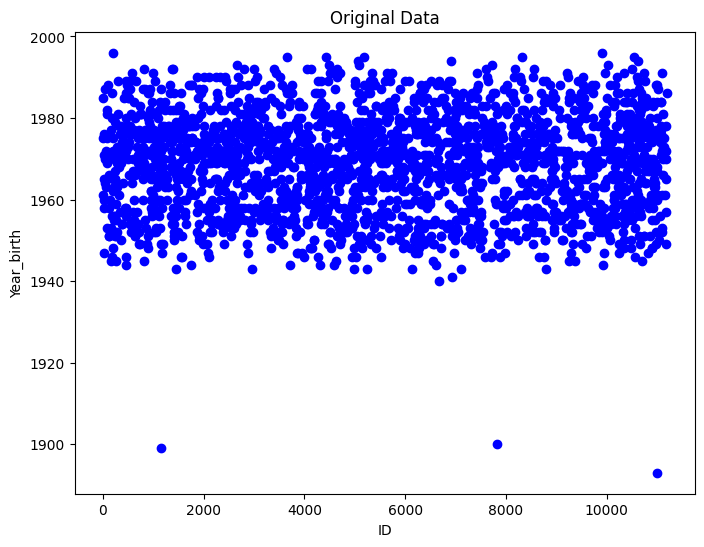

In [16]:
# Original data visualization
plt.figure(figsize=(8,6))
plt.scatter(
    x['ID'],
    x['Year_Birth'],
    color='blue'
)
plt.title("Original Data")
plt.xlabel("ID")
plt.ylabel("Year_birth")
plt.show()

In [17]:
#step 12: Feature scaling

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

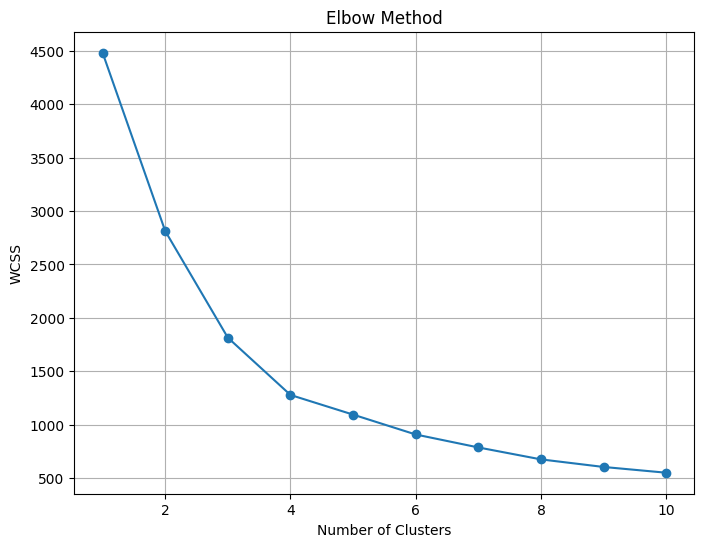

In [18]:
# ==========================================
# Step 13: Elbow Method
# ==========================================
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [19]:
#Train KMeans model
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(x_scaled)

In [20]:
# Add Cluster Column
data["Cluster"] = clusters

print(data.head())

      ID  Year_Birth   Education Marital_Status   Income   Kidhome  Teenhome  \
0   1826        1970  Graduation       Divorced   84835.0        0         0   
1      1        1961  Graduation         Single   57091.0        0         0   
2  10476        1958  Graduation        Married   67267.0        0         1   
3   1386        1967  Graduation       Together   32474.0        1         1   
4   5371        1989  Graduation         Single   21474.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2014-06-16        0       189  ...                  1             0   
1  2014-06-15        0       464  ...                  5             0   
2  2014-05-13        0       134  ...                  2             0   
3  2014-05-11        0        10  ...                  7             0   
4  2014-04-08        0         6  ...                  7             1   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Response  Compl

In [21]:
# Cluster Centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)

print(centers)

[[8641.51643836 1975.56849315]
 [2686.65360303 1975.02149178]
 [5692.61196106 1955.1015299 ]]


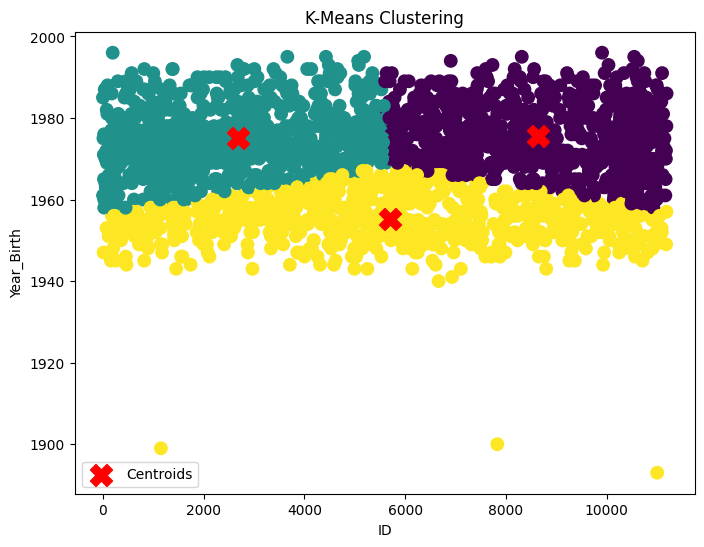

In [22]:
# Cluster Visualization
plt.figure(figsize=(8,6))
plt.scatter(
    data["ID"],
    data["Year_Birth"],
    c=data["Cluster"],
    cmap="viridis",
    s=80
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    color="red",
    marker="X",
    s=250,
    label="Centroids"
)
plt.title("K-Means Clustering")
plt.xlabel("ID")
plt.ylabel("Year_Birth")
plt.legend()
plt.show()

In [23]:
# Cluster Counts
print(data["Cluster"].value_counts())

Cluster
1    791
0    731
2    718
Name: count, dtype: int64


In [24]:
# Final Dataset
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Cluster
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,1,0,0,0,0,0,1,0,Spain,1
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,5,0,0,0,0,1,1,0,Canada,1
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,2,0,0,0,0,0,0,0,USA,2
3,1386,1967,Graduation,Together,32474.0,1,1,2014-05-11,0,10,...,7,0,0,0,0,0,0,0,Australia,1
4,5371,1989,Graduation,Single,21474.0,1,0,2014-04-08,0,6,...,7,1,0,0,0,0,1,0,Spain,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,2013-03-07,99,372,...,4,0,0,0,0,0,0,0,USA,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,2013-01-22,99,5,...,8,0,0,0,0,0,0,0,Spain,1
2237,22,1976,Graduation,Divorced,46310.0,1,0,2012-12-03,99,185,...,8,0,0,0,0,0,0,0,Spain,1
2238,528,1978,Graduation,Married,65819.0,0,0,2012-11-29,99,267,...,3,0,0,0,0,0,0,0,India,1


In [25]:
from sklearn.metrics import silhouette_score

In [26]:
# Calculate Silhouette Score
score = silhouette_score(x_scaled, clusters)

print("Silhouette Score :", round(score, 3))

Silhouette Score : 0.377


In [27]:
# Find Best K using Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)

    silhouette_scores.append(score)

    print(f"K = {k}  --->  Silhouette Score = {score:.3f}")

K = 2  --->  Silhouette Score = 0.357
K = 3  --->  Silhouette Score = 0.377
K = 4  --->  Silhouette Score = 0.383
K = 5  --->  Silhouette Score = 0.356
K = 6  --->  Silhouette Score = 0.372
K = 7  --->  Silhouette Score = 0.366
K = 8  --->  Silhouette Score = 0.359
K = 9  --->  Silhouette Score = 0.366
K = 10  --->  Silhouette Score = 0.355
